# Laboratory Task 4 (01_Understanding Deep Learning)


<div style="background-color: #d4e7d4; padding: 20px; border-radius: 8px; color: #2e4d2e; margin-bottom: 20px;">
  <p style="margin:0; font-size: 1.1em;"><strong>Course:</strong> DS Elective 4 - Deep Learning</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Name:</strong> Gem Nicole R. Diones</p>
  <p style="margin:0; font-size: 1.1em;"><strong>Year & Section:</strong> DS4A</p>
</div>

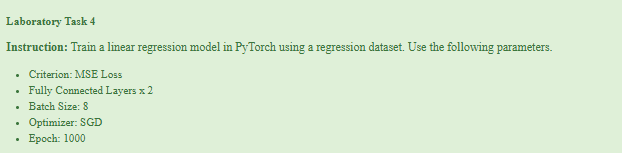

**Imports & Dataset Preparation**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

# Set manual seed for reproducible results
torch.manual_seed(42)

# Generate synthetic dataset (100 samples, 4 features)
X_data, y_data = make_regression(n_samples=100, n_features=4, noise=5.0, random_state=42)

# Scale features and targets for optimal SGD performance
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data.reshape(-1, 1))

# Convert numpy arrays to PyTorch Tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# Batch size constraint = 8
BATCH_SIZE = 8
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Dataset shape: {X_tensor.shape}")
print(f"Batches per epoch: {len(train_loader)}")

Dataset shape: torch.Size([100, 4])
Batches per epoch: 13


**Model Architecture Definition**

In [2]:
class RegressionNet(nn.Module):
    """
    Two-layer fully connected network architecture.
    Layer 1: Input -> Hidden (Linear + ReLU)
    Layer 2: Hidden -> Output (Linear)
    """
    def __init__(self, input_dim):
        super(RegressionNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 8)  # Layer 1
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)          # Layer 2

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Instantiate network
in_features = X_tensor.shape[1]
model = RegressionNet(input_dim=in_features)

print("--- Network Architecture ---")
print(model)

--- Network Architecture ---
RegressionNet(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


**Model Training & Optimization Loop**

In [3]:
# Task specifications setup
criterion = nn.MSELoss()                           # Criterion: MSE Loss
optimizer = optim.SGD(model.parameters(), lr=0.01) # Optimizer: SGD
EPOCHS = 1000                                      # Epochs: 1000

loss_history = []

print("Starting Model Training...")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0

    for batch_x, batch_y in train_loader:
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)

        # Backward pass & parameter update
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * batch_x.size(0)

    # Compute average loss over the entire dataset
    avg_loss = epoch_loss / len(train_loader.dataset)
    loss_history.append(avg_loss)

    # Log progress every 100 epochs
    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch [{epoch:4d}/{EPOCHS}] | Train Loss (MSE): {avg_loss:.6f}")

print("-" * 40)
print("Training Complete!")

Starting Model Training...
----------------------------------------
Epoch [   1/1000] | Train Loss (MSE): 0.782332
Epoch [ 100/1000] | Train Loss (MSE): 0.007718
Epoch [ 200/1000] | Train Loss (MSE): 0.005797
Epoch [ 300/1000] | Train Loss (MSE): 0.004668
Epoch [ 400/1000] | Train Loss (MSE): 0.004161
Epoch [ 500/1000] | Train Loss (MSE): 0.003873
Epoch [ 600/1000] | Train Loss (MSE): 0.003632
Epoch [ 700/1000] | Train Loss (MSE): 0.003291
Epoch [ 800/1000] | Train Loss (MSE): 0.003007
Epoch [ 900/1000] | Train Loss (MSE): 0.002846
Epoch [1000/1000] | Train Loss (MSE): 0.002785
----------------------------------------
Training Complete!


**Training Loss Visualization**

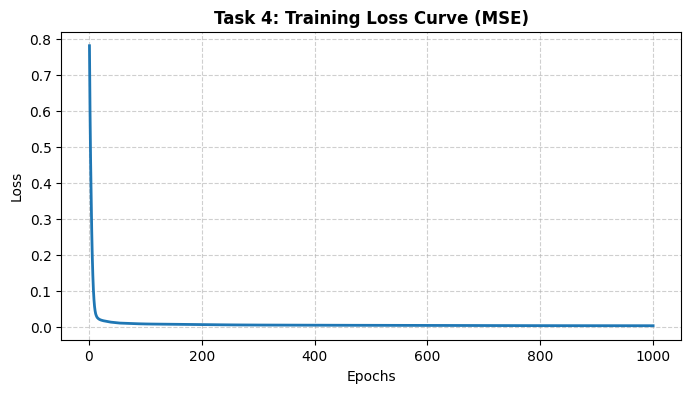

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4), dpi=100)
plt.plot(range(1, EPOCHS + 1), loss_history, color='#1f77b4', linewidth=2)
plt.title("Task 4: Training Loss Curve (MSE)", fontsize=12, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()